# Détectez des faux billets avec Python : notebook d'analyse

**Projet 12, parcours Data Analyst, ONCFM** · **Auteur :** Charles Lippens · **Date :** août 2026

Livrable n° 1 du projet : les traitements et les analyses qui mènent au choix du modèle de détection des faux billets, selon le cahier des charges de l'ONCFM et la fiche d'auto-évaluation.

## Point de départ

Le notebook suit le canevas du notebook de départ fourni avec le projet, p12_da_maj : ses six parties, 1) Chargement des données, 2) Analyse exploratoire (EDA), 3) Prétraitement, 4) Modélisation, Sélection du meilleur modèle, Sauvegarde du meilleur modèle, restent les titres de premier niveau, avec leurs textes et leurs consignes tels quels. Mes sections 1 à 10 s'y insèrent, et chaque consigne de départ est reprise en tête de la cellule qui y répond.

## Plan

1. Chargement et inspection
2. Analyse exploratoire
3. Tests statistiques
4. Valeurs manquantes : imputation par régression linéaire
5. Prétraitement supervisé : X et y, train/test, standardisation
6. Analyse en composantes principales
7. K-Means non supervisé
8. Les quatre modèles demandés
9. Évaluation et comparaison
10. Choix final, sauvegarde du pipeline, test de production

Chaque étape se termine par une courte lecture : ce qu'il faut retenir, en quelques phrases. Graines aléatoires fixées à 42 ; notebook exécuté de bout en bout, dans l'ordre, avant export.


# 1) Chargement des données

Allez, cadeau 😘:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "/content/billets.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "billets.csv"  # ajout : hors Colab, le fichier est placé à côté du notebook

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)
    print("⚠️ Tu as bien lu le code avant de l'executer ? 😏")


✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


## 1. Chargement des données : bibliothèques, reproductibilité et conversion de la cible

La cellule de départ a chargé le fichier ; on ajoute les bibliothèques de tout le notebook, la graine aléatoire et la conversion de la cible en 0/1.


In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.spatial.distance import cdist

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, StratifiedKFold)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             fbeta_score, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report,
                             silhouette_score, davies_bouldin_score)

import joblib
import sklearn

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

print("Environnement")
print("  scikit-learn :", sklearn.__version__)
print("  pandas       :", pd.__version__)
print("  numpy        :", np.__version__)
print("  statsmodels  :", sm.__version__)

Environnement
  scikit-learn : 1.6.1
  pandas       : 2.3.3
  numpy        : 2.2.6
  statsmodels  : 0.14.6


In [3]:
# is_genuine arrive en booléen : on le convertit en entier 0/1 pour que
# scikit-learn et les matrices de confusion travaillent sur la même convention.
df["is_genuine"] = df["is_genuine"].astype(int)
print("Dimensions :", df.shape)
print("Cible convertie :", df["is_genuine"].dtype, "| valeurs :", sorted(df["is_genuine"].unique().tolist()))


Dimensions : (1500, 7)
Cible convertie : int64 | valeurs : [0, 1]


### 1.1 Inspection initiale

Types, valeurs manquantes, doublons, statistiques descriptives, répartition de la cible.


In [4]:
print("Types :")
print(df.dtypes)
print()
print("Valeurs manquantes :")
print(df.isna().sum())
print()
print("Doublons :", df.duplicated().sum())

Types :
is_genuine        int64
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object

Valeurs manquantes :
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

Doublons : 0


In [5]:
df.describe().round(3)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000,1500.000,1500.000,1500.000,1463.000,1500.000,1500.000
mean,0.667,171.958,104.030,103.920,4.486,3.151,112.678
std,0.472,0.305,0.299,0.326,0.664,0.232,0.873
min,0.000,171.040,103.140,102.820,2.980,2.270,109.490
25%,0.000,171.750,103.820,103.710,4.015,2.990,112.030
50%,1.000,171.960,104.040,103.920,4.310,3.140,112.960
75%,1.000,172.170,104.230,104.150,4.870,3.310,113.340
max,1.000,173.010,104.880,104.950,6.900,3.910,114.440


In [6]:
counts = df["is_genuine"].value_counts().rename({1: "Vrai", 0: "Faux"})
print(counts)
print("Proportions :", (counts / counts.sum()).round(3).to_dict())

is_genuine
Vrai    1000
Faux     500
Name: count, dtype: int64
Proportions : {'Vrai': 0.667, 'Faux': 0.333}


**Ce que disent ces contrôles.** 1 500 billets, 7 colonnes, types corrects, aucun doublon. 1 000 vrais et 500 faux, deux tiers contre un tiers : le découpage train/test sera stratifié. 37 valeurs manquantes, toutes sur margin_low, soit 2,5 % des lignes : on les imputera plutôt que de supprimer les lignes.

# 2) Analyse exploratoire (EDA)


Là, c'est vous les pro 💪, je vous fais entièrement confiance 😉 !

Pssst (indice) : trouvez des variables corrélées à votre objectif, ça marche mieux 😉.

## 2. Analyse exploratoire

### 2.1 Distributions par classe

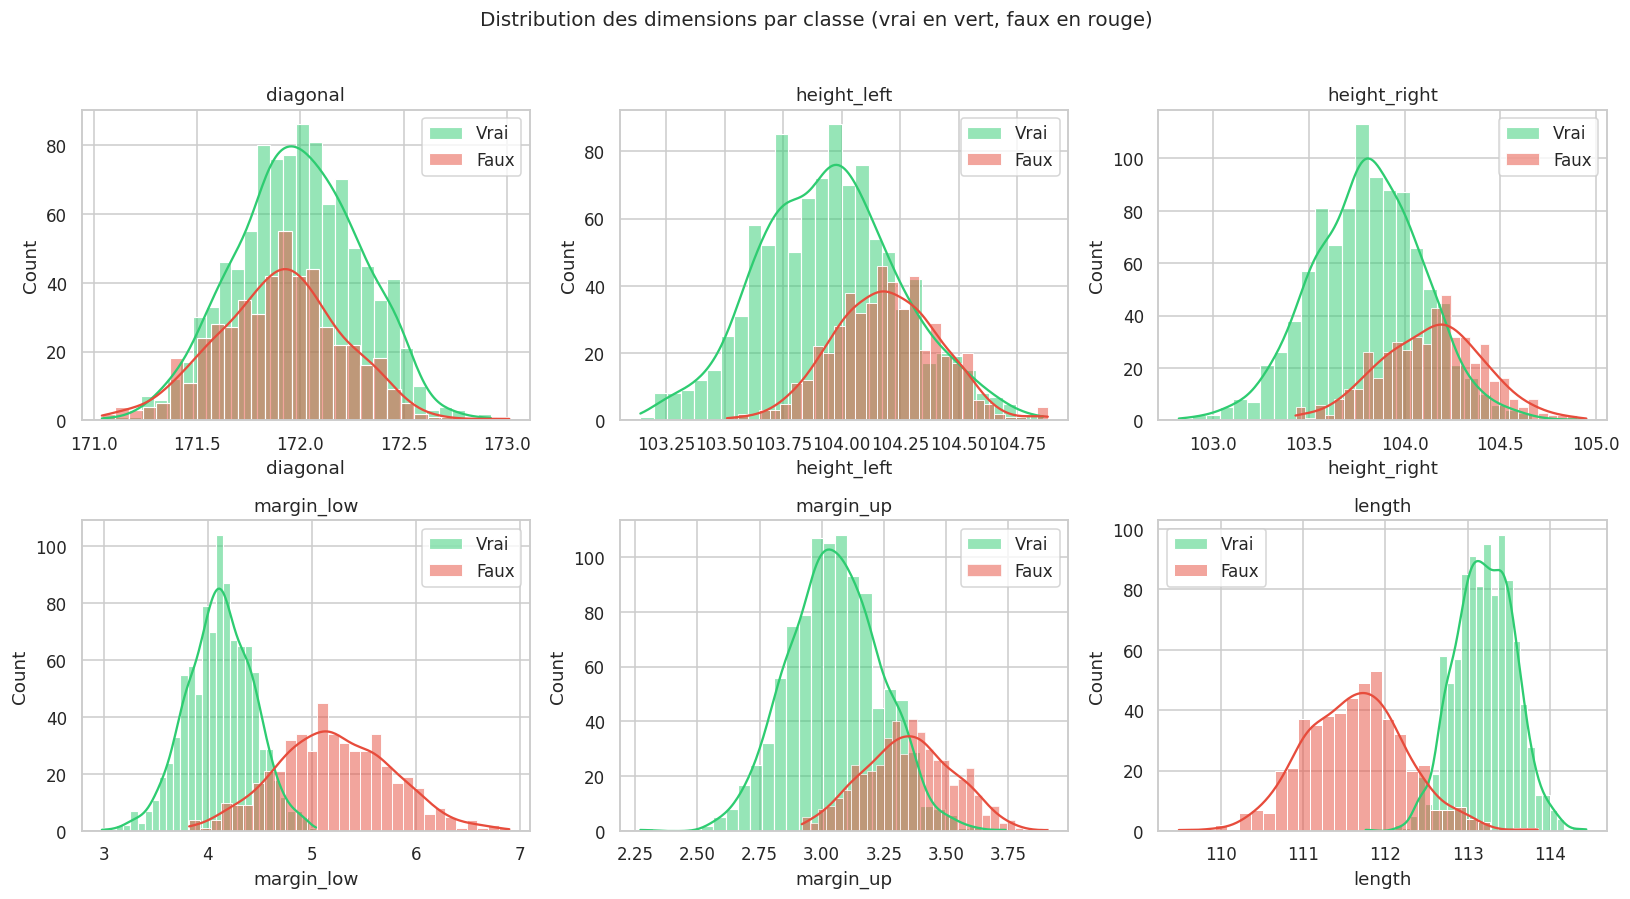

In [7]:
features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

palette_classes = {1: "#2ECC71", 0: "#E74C3C"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), features):
    for cls, color in palette_classes.items():
        sns.histplot(data=df[df["is_genuine"] == cls], x=col, kde=True, ax=ax,
                     bins=30, color=color, alpha=0.5,
                     label=("Vrai" if cls == 1 else "Faux"))
    ax.set_title(col)
    ax.legend()
fig.suptitle("Distribution des dimensions par classe (vrai en vert, faux en rouge)",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Lecture des distributions.** Sur les six dimensions, les histogrammes des vrais (vert) et des faux (rouge) sont décalés. L'écart est net pour length, les faux étant plus courts, et pour margin_low, les faux ayant une marge basse plus large ; il est faible pour diagonal. Les deux populations se recouvrent un peu : il y aura quelques erreurs de classement.

### 2.2 Boîtes à moustaches par classe

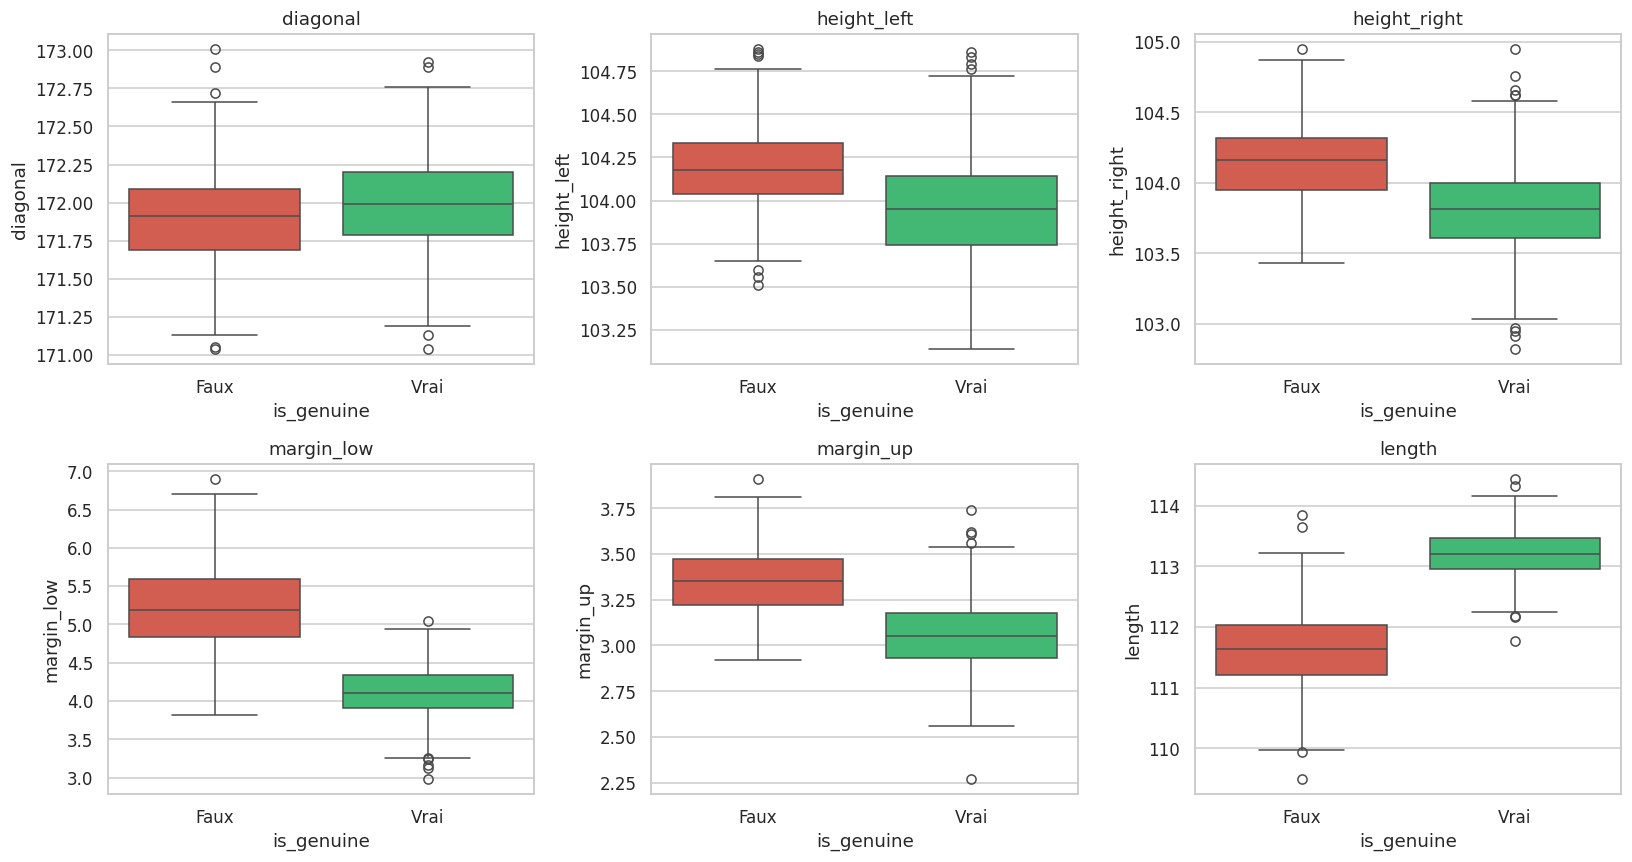

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="is_genuine", y=col, ax=ax,
                hue="is_genuine", legend=False,
                palette={0: "#E74C3C", 1: "#2ECC71"})
    ax.set_title(col)
    ax.set_xticklabels(["Faux", "Vrai"])
plt.tight_layout()
plt.show()

**Lecture des boîtes à moustaches.** Les boîtes confirment les décalages de médianes, surtout pour length, margin_low et margin_up, et montrent quelques points isolés au-delà des moustaches. Ils sont examinés en 2.4 avant toute décision.

### 2.3 Moyennes par classe et écarts

In [9]:
means = df.groupby("is_genuine")[features].mean().round(3)
means.index = ["Faux", "Vrai"]
means.T.assign(écart=lambda d: (d["Vrai"] - d["Faux"]).round(3))

,Faux,Vrai,écart
diagonal,171.901,171.987,0.086
height_left,104.190,103.949,-0.241
height_right,104.144,103.809,-0.335
margin_low,5.216,4.116,-1.100
margin_up,3.350,3.052,-0.298
length,111.631,113.202,1.571


**Lecture des écarts.** Un faux billet est en moyenne plus court de 1,57 mm, avec une marge basse plus large de 1,10 mm et une marge haute plus large de 0,30 mm ; ses hauteurs dépassent de 0,24 et 0,34 mm, sa diagonale diffère de 0,09 mm à peine. Des écarts invisibles à l'œil nu, exactement ce qu'une machine peut exploiter.

### 2.4 Valeurs atypiques

Règle de Tukey : est atypique toute valeur à plus de 1,5 écart interquartile en dehors des quartiles. Combien de points, et sur quelle classe ?


In [10]:
lignes = []
masque_atypique = pd.Series(False, index=df.index)

for col in features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    borne_basse, borne_haute = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    hors = (df[col] < borne_basse) | (df[col] > borne_haute)
    masque_atypique |= hors.fillna(False)
    lignes.append({
        "variable": col,
        "borne basse": round(borne_basse, 3),
        "borne haute": round(borne_haute, 3),
        "nb atypiques": int(hors.sum()),
        "part (%)": round(100 * hors.sum() / df[col].notna().sum(), 2),
        "dont faux": int((hors & (df["is_genuine"] == 0)).sum()),
        "dont vrais": int((hors & (df["is_genuine"] == 1)).sum()),
    })

atypiques = pd.DataFrame(lignes)
print("Lignes contenant au moins une valeur atypique :",
      int(masque_atypique.sum()), f"({100 * masque_atypique.sum() / len(df):.1f} %)")
atypiques

Lignes contenant au moins une valeur atypique : 53 (3.5 %)


,variable,borne basse,borne haute,nb atypiques,part (%),dont faux,dont vrais
0,diagonal,171.120,172.800,7,0.47,4,3
1,height_left,103.205,104.845,6,0.40,3,3
2,height_right,103.050,104.810,11,0.73,4,7
3,margin_low,2.732,6.153,24,1.64,24,0
4,margin_up,2.510,3.790,3,0.20,2,1
5,length,110.065,115.305,3,0.20,3,0


**Décision : on garde tout.**

53 lignes sur 1 500, soit 3,5 %, ont au moins une valeur hors bornes. Les 24 points atypiques de margin_low et les 3 de length sont tous des faux billets : des contrefaçons mal imitées, donc des cas utiles à apprendre, pas du bruit. Les autres points se répartissent entre les deux classes et restent dans des plages plausibles. Aucune suppression ; la standardisation ramènera les échelles, et le random forest, insensible aux valeurs extrêmes, servira de contrôle.

### 2.5 Corrélations et colinéarité

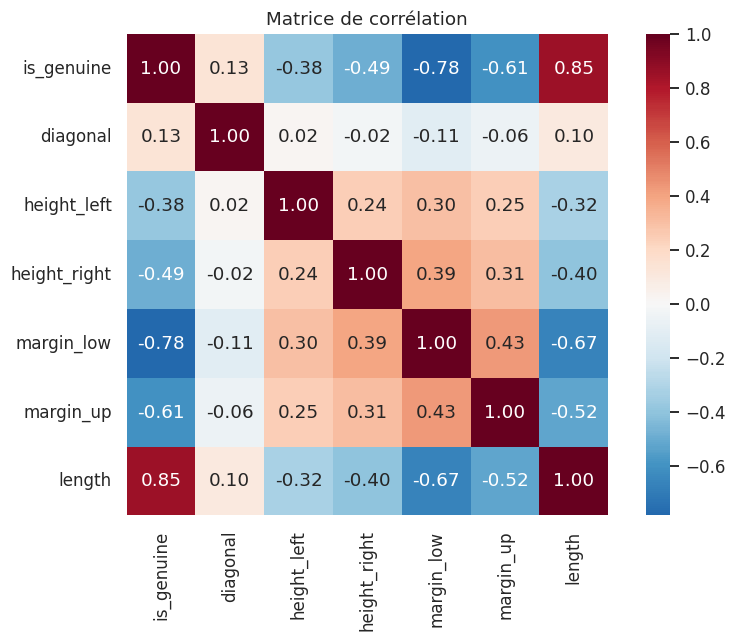

Corrélations avec la cible :
length          0.849
diagonal        0.133
height_left    -0.380
height_right   -0.485
margin_up      -0.606
margin_low     -0.783
Name: is_genuine, dtype: float64

Corrélation maximale entre deux variables explicatives : 0.667 (margin_low et length)
Trois couples les plus liés :
  margin_low et length : -0.667
  margin_up et length : -0.521
  margin_low et margin_up : +0.432


In [11]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

print("Corrélations avec la cible :")
print(corr["is_genuine"].drop("is_genuine").sort_values(ascending=False).round(3))

print()
expl = corr.loc[features, features].abs().to_numpy(copy=True)
np.fill_diagonal(expl, 0.0)
i, j = np.unravel_index(expl.argmax(), expl.shape)
print(f"Corrélation maximale entre deux variables explicatives : {expl.max():.3f} "
      f"({features[i]} et {features[j]})")

# Les trois couples les plus corrélés entre variables explicatives
paires = []
for a in range(len(features)):
    for b in range(a + 1, len(features)):
        paires.append((abs(corr.loc[features[a], features[b]]), features[a], features[b]))
paires.sort(reverse=True)
print("Trois couples les plus liés :")
for v, va, vb in paires[:3]:
    print(f"  {va} et {vb} : {corr.loc[va, vb]:+.3f}")

La corrélation la plus forte entre variables explicatives, -0,67 entre margin_low et length, est attendue : ce sont les deux variables les plus liées à la nature du billet. Le facteur d'inflation de la variance, VIF, dit si cette liaison gêne un modèle linéaire ; seuil d'alerte à 5, seuil critique à 10.


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(df[features].dropna())
vif = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, k) for k in range(X_vif.shape[1])],
}).query("variable != 'const'").round(2)
vif["lecture"] = np.where(vif["VIF"] < 5, "acceptable",
                          np.where(vif["VIF"] < 10, "à surveiller", "problématique"))
vif

,variable,VIF,lecture
1,diagonal,1.02,acceptable
2,height_left,1.15,acceptable
3,height_right,1.26,acceptable
4,margin_low,1.91,acceptable
5,margin_up,1.42,acceptable
6,length,2.13,acceptable


**Lecture.** Avec la cible, length (+0,85) et margin_low (-0,78) sont les plus corrélées. Tous les VIF sont sous 2,2, loin du seuil de 5 : la colinéarité est modérée, les six variables sont conservées.

## 3. Tests statistiques

Les graphiques suggèrent des dimensions différentes entre vrais et faux billets ; les tests le démontrent. Démarche du cours « Explorez les tests statistiques » : vérifier les conditions d'application, choisir le test, lire la p-valeur sans la confondre avec l'importance de l'écart.


### 3.1 Normalité des distributions par classe (Shapiro-Wilk)

H0 : l'échantillon suit une loi normale ; rejet si p < 0,05. Test par variable et par classe, car c'est la normalité dans chaque groupe qui conditionne le test t.


In [13]:
res_norm = []
for col in features:
    for cls, nom in [(1, "Vrai"), (0, "Faux")]:
        echantillon = df.loc[df["is_genuine"] == cls, col].dropna()
        stat, p = stats.shapiro(echantillon)
        res_norm.append({
            "variable": col, "classe": nom, "n": len(echantillon),
            "W": round(stat, 4), "p_value": p,
            "normalité (alpha=0,05)": "non rejetée" if p >= 0.05 else "rejetée",
        })

normalite = pd.DataFrame(res_norm)
normalite

,variable,classe,n,W,p_value,"normalité (alpha=0,05)"
0,diagonal,Vrai,1000,0.9981,0.311966,non rejetée
1,diagonal,Faux,500,0.9974,0.638517,non rejetée
2,height_left,Vrai,1000,0.9966,0.028689,rejetée
3,height_left,Faux,500,0.9979,0.790502,non rejetée
4,height_right,Vrai,1000,0.9985,0.586376,non rejetée
5,height_right,Faux,500,0.9980,0.826522,non rejetée
6,margin_low,Vrai,971,0.9984,0.499942,non rejetée
7,margin_low,Faux,492,0.9972,0.555381,non rejetée
8,margin_up,Vrai,1000,0.9982,0.355047,non rejetée
9,margin_up,Faux,500,0.9957,0.192711,non rejetée


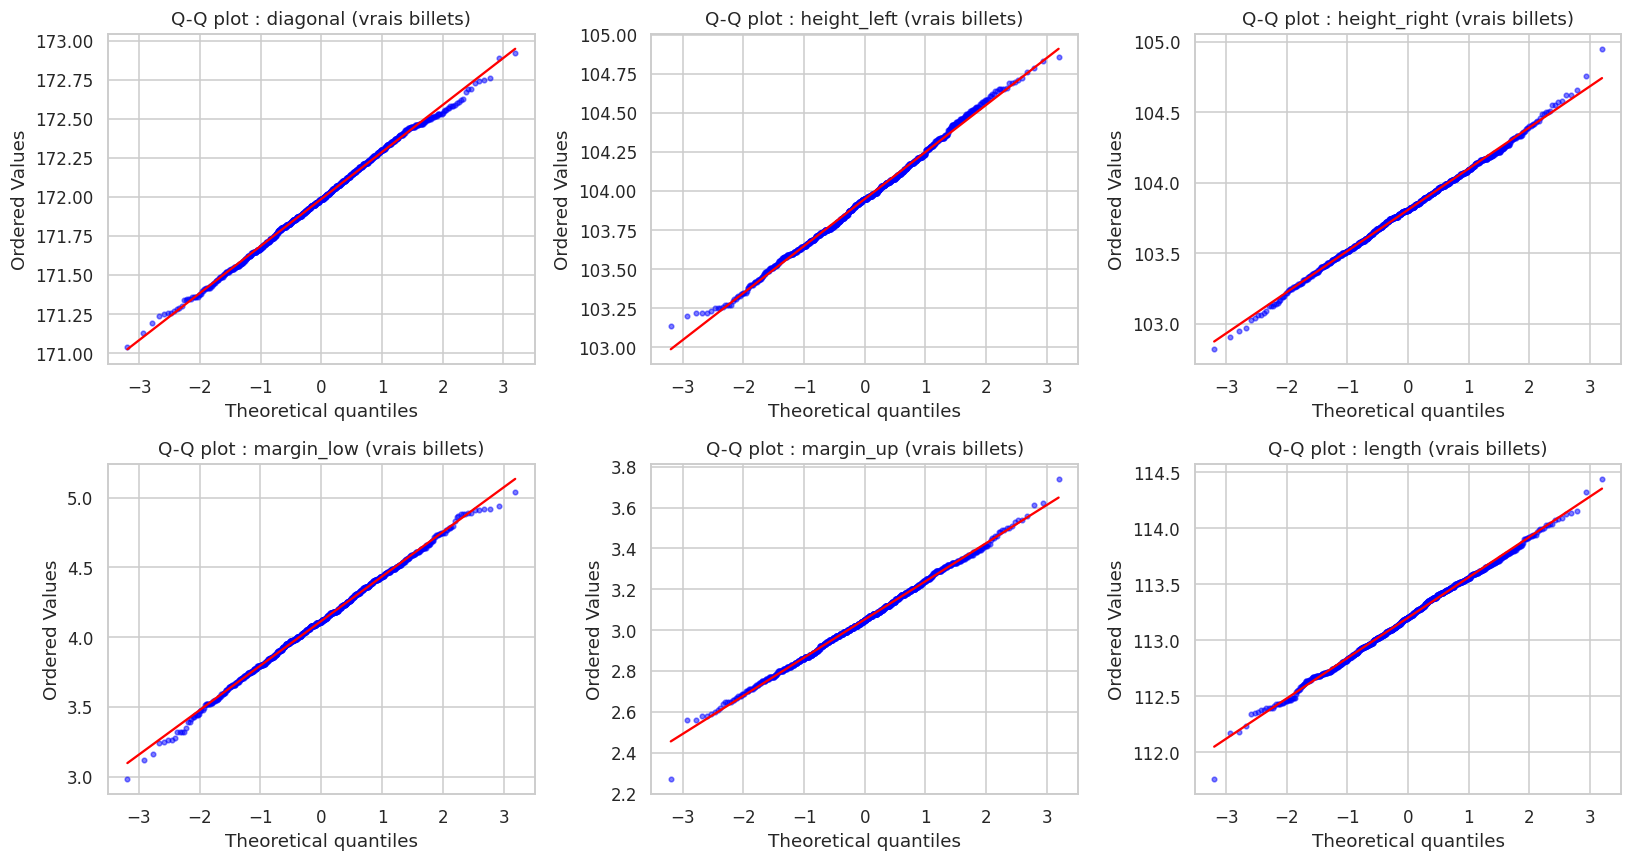

In [14]:
# Contrôle visuel : diagramme quantile-quantile pour chaque variable, classe des vrais billets.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), features):
    stats.probplot(df.loc[df["is_genuine"] == 1, col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot : {col} (vrais billets)")
    ax.get_lines()[0].set_markersize(3)
    ax.get_lines()[0].set_alpha(0.5)
plt.tight_layout()
plt.show()

**Lecture.** Normalité non rejetée dans 11 cas sur 12 ; le seul rejet, height_left chez les vrais billets (p = 0,029), est proche du seuil et tient à l'effectif de 1 000. Les diagrammes quantile-quantile suivent la diagonale sauf aux extrémités. Un test paramétrique est possible ; reste à vérifier l'égalité des variances.

### 3.2 Égalité des variances (test de Levene)

Le test t classique suppose des variances égales. Levene teste H0 : variances égales ; s'il rejette, on passe à la variante de Welch.


In [15]:
res_levene = []
for col in features:
    a = df.loc[df["is_genuine"] == 1, col].dropna()
    b = df.loc[df["is_genuine"] == 0, col].dropna()
    stat, p = stats.levene(a, b, center="median")
    res_levene.append({
        "variable": col,
        "var. vrais": round(a.var(ddof=1), 4),
        "var. faux": round(b.var(ddof=1), 4),
        "statistique W": round(stat, 3),
        "p_value": p,
        "variances égales (alpha=0,05)": "oui" if p >= 0.05 else "non",
    })

pd.DataFrame(res_levene)

,variable,var. vrais,var. faux,statistique W,p_value,"variances égales (alpha=0,05)"
0,diagonal,0.0903,0.0942,0.011,9.168220e-01,oui
1,height_left,0.0901,0.0501,42.732,8.585413e-11,non
2,height_right,0.0850,0.0734,1.918,1.662545e-01,oui
3,margin_low,0.1018,0.3064,191.940,4.217216e-41,non
4,margin_up,0.0347,0.0326,0.182,6.699473e-01,oui
5,length,0.1293,0.3789,172.059,2.737469e-37,non


**Conséquence pour le choix du test.** Levene rejette l'égalité des variances sur height_left, margin_low et length. Le test t de Welch (equal_var=False) est donc retenu ; quand les variances sont égales, il donne pratiquement le même résultat que Student, le choix est sans coût.

### 3.3 Comparaison des moyennes : test t de Welch

H0 : même moyenne chez les vrais et les faux ; test bilatéral à 5 %. Le d de Cohen mesure l'écart en écarts-types et distingue ce qui est détectable de ce qui est important.


In [16]:
def cohen_d(a, b):
    # Taille d'effet standardisée pour deux échantillons indépendants.
    na, nb = len(a), len(b)
    s = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / s


def lire_effet(d):
    ad = abs(d)
    if ad < 0.2:
        return "négligeable"
    if ad < 0.5:
        return "faible"
    if ad < 0.8:
        return "moyen"
    return "fort"


rows = []
for col in features:
    a = df.loc[df["is_genuine"] == 1, col].dropna()
    b = df.loc[df["is_genuine"] == 0, col].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    d = cohen_d(a, b)
    rows.append({
        "variable": col,
        "t (Welch)": round(t, 2),
        "p_value": p,
        "significatif (alpha=0,05)": p < 0.05,
        "écart des moyennes (mm)": round(a.mean() - b.mean(), 3),
        "d de Cohen": round(d, 2),
        "taille d'effet": lire_effet(d),
    })

tests_welch = pd.DataFrame(rows)
tests_welch

,variable,t (Welch),p_value,"significatif (alpha=0,05)",écart des moyennes (mm),d de Cohen,taille d'effet
0,diagonal,5.15,3.186900e-07,True,0.086,0.28,faible
1,height_left,-17.49,1.415363e-61,True,-0.241,-0.87,fort
2,height_right,-22.00,9.287594e-89,True,-0.335,-1.18,fort
3,margin_low,-40.77,1.433175e-182,True,-1.100,-2.66,fort
4,margin_up,-29.82,2.927401e-141,True,-0.298,-1.62,fort
5,length,52.77,1.469955e-241,True,1.572,3.41,fort


**Lecture des tests.** Les six dimensions diffèrent significativement, toutes les p-valeurs sont inférieures à 10 puissance -6. Les tailles d'effet classent les variables : d = 3,41 pour length et 2,66 pour margin_low, effets très forts ; 1,62 pour margin_up, 1,18 pour height_right, 0,87 pour height_left ; 0,28 seulement pour diagonal, effet faible. diagonal est significative parce que l'échantillon est grand, pas parce que l'écart est important.

### 3.4 Confirmation non paramétrique : test de Mann-Whitney

Contrôle sans hypothèse de loi : Mann-Whitney compare les rangs. Si les deux familles de tests concordent, la conclusion ne dépend plus d'une hypothèse de distribution.


In [17]:
rows = []
for col in features:
    a = df.loc[df["is_genuine"] == 1, col].dropna()
    b = df.loc[df["is_genuine"] == 0, col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    rows.append({"variable": col, "U": round(u, 1), "p_value": p,
                 "significatif (alpha=0,05)": p < 0.05})

comparaison = pd.DataFrame(rows).merge(
    tests_welch[["variable", "p_value", "significatif (alpha=0,05)"]],
    on="variable", suffixes=(" Mann-Whitney", " Welch"))
comparaison

,variable,U,p_value Mann-Whitney,"significatif (alpha=0,05) Mann-Whitney",p_value Welch,"significatif (alpha=0,05) Welch"
0,diagonal,289509.0,5.850271e-07,True,3.186900e-07,True
1,height_left,128779.0,4.883939e-53,True,1.415363e-61,True
2,height_right,99224.5,4.807965e-81,True,9.287594e-89,True
3,margin_low,19094.0,3.046593e-182,True,1.433175e-182,True
4,margin_up,63494.0,5.419133e-123,True,2.927401e-141,True
5,length,491978.5,1.288000e-205,True,1.469955e-241,True


**Synthèse de la partie statistique**

Mann-Whitney confirme les six résultats. Les six dimensions séparent les classes ; length (écart 1,57 mm, d = 3,41) et margin_low (1,10 mm, d = 2,66) portent l'essentiel du signal, diagonal presque rien (0,09 mm, d = 0,28) : elle est gardée parce qu'elle ne nuit pas. Les corrélations avec la cible donnent le même ordre ; les VIF sont maîtrisés ; les échelles vont de 3 mm à 113 mm, la standardisation est donc obligatoire pour les modèles linéaires et à distances.

# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


## 4. Traitement des valeurs manquantes

Option retenue : imputer margin_low par une régression linéaire sur les cinq autres dimensions. Supprimer les 37 lignes coûterait 2,5 % du jeu sur une variable très discriminante ; remplacer par la moyenne écraserait la variabilité et rapprocherait les faux des vrais. Le modèle n'utilise pas is_genuine : en production, la nature du billet est justement l'inconnue.


In [18]:
mask_known = df["margin_low"].notna()
predictors = ["diagonal", "height_left", "height_right", "margin_up", "length"]

X_known = sm.add_constant(df.loc[mask_known, predictors])
y_known = df.loc[mask_known, "margin_low"]

ols = sm.OLS(y_known, X_known).fit()
print(ols.summary().tables[0])
print()
print(ols.summary().tables[1])
print(f"R2 : {ols.rsquared:.3f}   R2 ajusté : {ols.rsquared_adj:.3f}")

                            OLS Regression Results                            
Dep. Variable:             margin_low   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     266.1
Date:                Wed, 19 Aug 2026   Prob (F-statistic):          2.60e-202
Time:                        11:37:08   Log-Likelihood:                -1001.3
No. Observations:                1463   AIC:                             2015.
Df Residuals:                    1457   BIC:                             2046.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           22.9948      9.656      2.382  

### 4.1 Diagnostic des résidus du modèle d'imputation

Un modèle de régression ne vaut que si ses résidus se comportent bien, centrés, de variance stable, sans structure, et si ses prédicteurs ne sont pas colinéaires. Contrôle graphique, puis par tests : Shapiro-Wilk pour la normalité des résidus, Breusch-Pagan pour l'homoscédasticité, VIF pour la colinéarité.


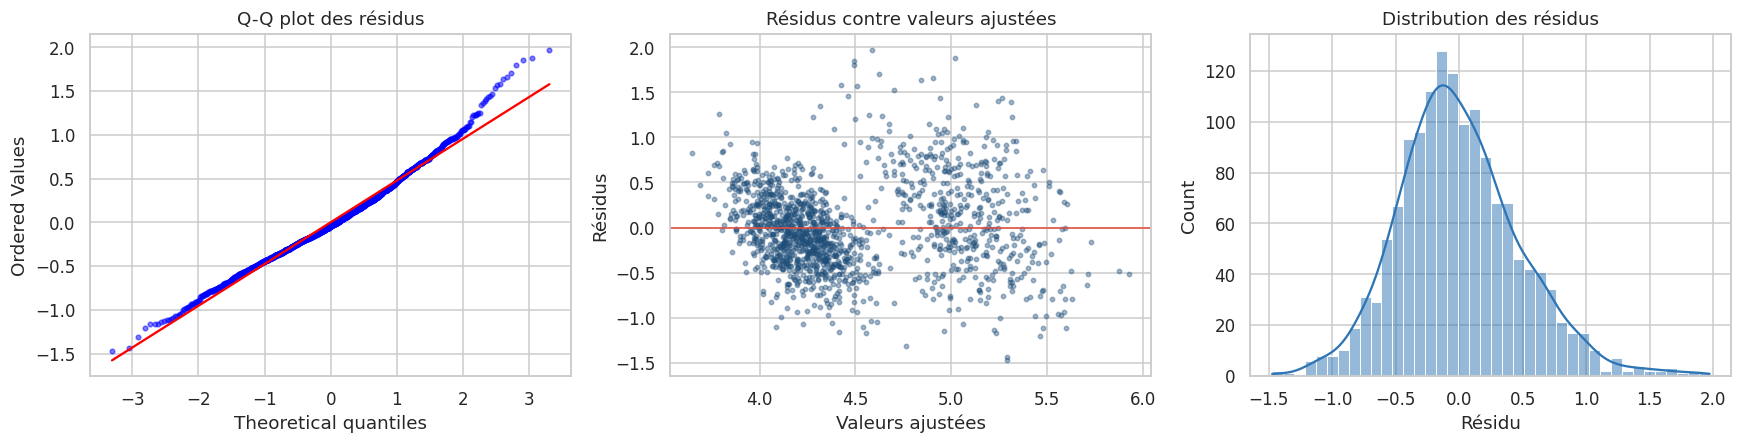

Shapiro-Wilk sur les résidus : W = 0.9858, p = 8.54e-11
Moyenne des résidus : -1.49e-14   Écart-type : 0.4799
Asymétrie : 0.482   Aplatissement : 0.801
Breusch-Pagan : LM = 80.16, p = 7.76e-16
Écart-type des résidus par tiers de valeur ajustée : {'tiers bas': 0.364, 'tiers milieu': 0.406, 'tiers haut': 0.596}
VIF des prédicteurs : {'diagonal': 1.01, 'height_left': 1.14, 'height_right': 1.23, 'margin_up': 1.4, 'length': 1.58}


In [19]:
residus = ols.resid
ajustes = ols.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# Q-Q plot des résidus
stats.probplot(residus, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot des résidus")
axes[0].get_lines()[0].set_markersize(3)
axes[0].get_lines()[0].set_alpha(0.5)

# Résidus contre valeurs ajustées
axes[1].scatter(ajustes, residus, s=8, alpha=0.4, color="#1F4E79")
axes[1].axhline(0, color="#E74C3C", lw=1)
axes[1].set_xlabel("Valeurs ajustées")
axes[1].set_ylabel("Résidus")
axes[1].set_title("Résidus contre valeurs ajustées")

# Histogramme des résidus
sns.histplot(residus, kde=True, ax=axes[2], color="#2E75B6", bins=40)
axes[2].set_title("Distribution des résidus")
axes[2].set_xlabel("Résidu")

plt.tight_layout()
plt.show()

stat_sh, p_sh = stats.shapiro(residus)
print(f"Shapiro-Wilk sur les résidus : W = {stat_sh:.4f}, p = {p_sh:.4g}")
print(f"Moyenne des résidus : {residus.mean():.2e}   Écart-type : {residus.std(ddof=1):.4f}")
print(f"Asymétrie : {stats.skew(residus):.3f}   Aplatissement : {stats.kurtosis(residus):.3f}")

# Homoscédasticité : test de Breusch-Pagan (H0 : variance des résidus constante)
from statsmodels.stats.diagnostic import het_breuschpagan
lm_stat, lm_p, f_stat, f_p = het_breuschpagan(residus, X_known)
print(f"Breusch-Pagan : LM = {lm_stat:.2f}, p = {lm_p:.3g}")
tiers = pd.qcut(ajustes, 3, labels=["tiers bas", "tiers milieu", "tiers haut"])
print("Écart-type des résidus par tiers de valeur ajustée :",
      residus.groupby(tiers, observed=True).std().round(3).to_dict())

# Colinéarité des cinq prédicteurs : VIF
vif_pred = {col: round(float(variance_inflation_factor(X_known.values, k)), 2)
            for k, col in enumerate(X_known.columns) if col != "const"}
print("VIF des prédicteurs :", vif_pred)


**Lecture du diagnostic.** R² de 0,477, ajusté 0,476 : les cinq autres dimensions expliquent un peu moins de la moitié de la variance de margin_low, bien mieux que la moyenne, dont le R² est nul ; les six coefficients sont significatifs, length négatif, hauteurs et marge haute positifs. Résidus centrés, écart-type 0,48 mm, VIF des prédicteurs entre 1,0 et 1,6. Deux hypothèses sont rejetées : la normalité des résidus, Shapiro-Wilk, asymétrie 0,48 et queues un peu lourdes ; et l'homoscédasticité, Breusch-Pagan, la dispersion des résidus augmentant avec la valeur ajustée, 0,36 mm dans le tiers bas contre 0,60 mm dans le tiers haut, là où se trouvent les faux billets. Conséquence : les écarts-types et les p-valeurs du tableau se lisent avec prudence, ils conditionnent l'inférence ; la prédiction ponctuelle, seule utilisée pour imputer 37 valeurs, reste valable.

In [20]:
# Imputation proprement dite
X_missing = sm.add_constant(df.loc[~mask_known, predictors], has_constant="add")
valeurs_imputees = ols.predict(X_missing)
df.loc[~mask_known, "margin_low"] = valeurs_imputees

assert df.isna().sum().sum() == 0, "Il reste des valeurs manquantes"
print("Imputation terminée, aucune valeur manquante restante.")
print(f"Valeurs imputées : {len(valeurs_imputees)}  "
      f"(min {valeurs_imputees.min():.2f} / max {valeurs_imputees.max():.2f})")

Imputation terminée, aucune valeur manquante restante.
Valeurs imputées : 37  (min 3.61 / max 5.73)


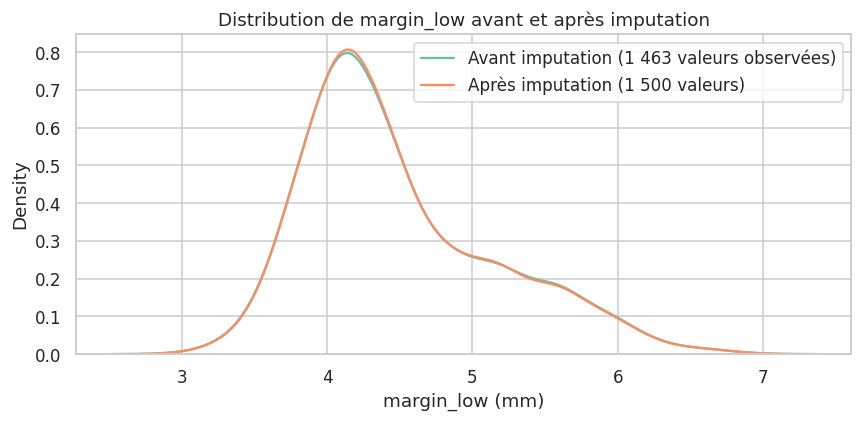

,avant (observé),après (complet)
count,1463.000,1500.000
mean,4.486,4.483
std,0.664,0.660
min,2.980,2.980
25%,4.015,4.020
50%,4.310,4.310
75%,4.870,4.870
max,6.900,6.900


In [21]:
# Vérification : la distribution de la variable n'a pas été déformée
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(df.loc[mask_known, "margin_low"], label="Avant imputation (1 463 valeurs observées)", ax=ax)
sns.kdeplot(df["margin_low"], label="Après imputation (1 500 valeurs)", ax=ax)
ax.set_title("Distribution de margin_low avant et après imputation")
ax.set_xlabel("margin_low (mm)")
ax.legend()
plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    "avant (observé)": df.loc[mask_known, "margin_low"].describe(),
    "après (complet)": df["margin_low"].describe(),
}).round(3)
comp

**Contrôle de la distribution.** Les 37 valeurs imputées vont de 3,61 à 5,73 mm, dans la plage observée ; les deux courbes de densité se superposent, moyenne 4,486 puis 4,483, écart-type 0,664 puis 0,660. La variable est complète, sans déformation.

### 4.2 Contrôle de la fuite d'information liée à l'imputation

Le modèle d'imputation est ajusté sur les 1 463 valeurs observées, donc avant la séparation train/test. On mesure la fuite d'information possible en refaisant l'imputation avec un modèle ajusté sur le seul entraînement.


In [22]:
# On rejoue l'imputation en mode strictement "fit on train"
df_ctrl = pd.read_csv(DATA_PATH, sep=";")
df_ctrl["is_genuine"] = df_ctrl["is_genuine"].astype(int)

idx_train, idx_test = train_test_split(
    df_ctrl.index, test_size=0.20, stratify=df_ctrl["is_genuine"],
    random_state=RANDOM_STATE)

connu_train = df_ctrl.loc[idx_train].dropna(subset=["margin_low"])
ols_train = sm.OLS(connu_train["margin_low"],
                   sm.add_constant(connu_train[predictors])).fit()

manquants = df_ctrl["margin_low"].isna()
imput_train_only = ols_train.predict(
    sm.add_constant(df_ctrl.loc[manquants, predictors], has_constant="add"))

ecarts = (imput_train_only - valeurs_imputees).abs()
print(f"R2 ajusté, modèle ajusté sur tout      : {ols.rsquared_adj:.4f}")
print(f"R2 ajusté, modèle ajusté sur le train  : {ols_train.rsquared_adj:.4f}")
print()
print("Écart absolu entre les deux séries de valeurs imputées (mm)")
print(f"  moyen   : {ecarts.mean():.4f}")
print(f"  maximal : {ecarts.max():.4f}")
print(f"  à comparer à l'écart-type de margin_low : {df['margin_low'].std():.4f}")

R2 ajusté, modèle ajusté sur tout      : 0.4755
R2 ajusté, modèle ajusté sur le train  : 0.4814

Écart absolu entre les deux séries de valeurs imputées (mm)
  moyen   : 0.0088
  maximal : 0.0303
  à comparer à l'écart-type de margin_low : 0.6596


**Conclusion du contrôle.** Écart maximal de 0,03 mm entre les deux séries de valeurs imputées, pour un écart-type de 0,66 mm ; R² ajusté identique à la deuxième décimale. La fuite est négligeable : l'imputation sur jeu complet est conservée, et le modèle ols sera sauvegardé avec le pipeline pour traiter les valeurs manquantes en production.

## 5. Prétraitement supervisé : séparation des variables, train/test et standardisation

Suite de la partie 3) du notebook de départ : ses trois consignes sont reprises telles quelles, chacune suivie de la cellule qui y répond. Deux précautions : séparation stratifiée, qui garde deux tiers de vrais et un tiers de faux dans chaque jeu ; standardisation ajustée sur le seul entraînement, pour ne pas laisser le jeu de test influencer l'apprentissage. L'ACP et le K-Means non supervisé travailleront à part, sur les 1 500 billets : ils décrivent la structure, ils ne prédisent pas.


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

In [23]:
# Cellule du notebook de départ, à compléter :
# X = df[[]] # Toutes les colonnes sauf la cible
# y = df[""] # La colonne cible
X_full = df[features]         # toutes les colonnes sauf la cible, les six dimensions
y_full = df["is_genuine"]     # la colonne cible
print("X :", X_full.shape, "  y :", y_full.shape)


X : (1500, 6)   y : (1500,)


Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

In [24]:
from sklearn.model_selection import train_test_split

# Cellule du notebook de départ, à compléter :
# X_train, X_test, y_train, y_test = # utilisez train_test_split de la librairy Sklearn
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.20, stratify=y_full, random_state=RANDOM_STATE)

print("Train :", X_train.shape, "  Test :", X_test.shape)
print("Proportions train :", y_train.value_counts(normalize=True).round(3).to_dict())
print("Proportions test  :", y_test.value_counts(normalize=True).round(3).to_dict())
print("Effectifs test    :", y_test.value_counts().rename({0: "Faux", 1: "Vrai"}).to_dict())


Train : (1200, 6)   Test : (300, 6)
Proportions train : {1: 0.667, 0: 0.333}
Proportions test  : {1: 0.667, 0: 0.333}
Effectifs test    : {'Vrai': 200, 'Faux': 100}


Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Use scaler on X_train and X_test.   (consigne du notebook de départ)
scaler.fit(X_train)                       # ajusté sur le seul jeu d'entraînement
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)
print("Standardisation effectuée, paramètres ajustés sur le train uniquement.")
print("Moyennes apprises :", np.round(scaler.mean_, 3))
print("Écarts-types      :", np.round(scaler.scale_, 3))


Standardisation effectuée, paramètres ajustés sur le train uniquement.
Moyennes apprises : [171.96  104.032 103.919   4.49    3.152 112.668]
Écarts-types      : [0.3   0.3   0.322 0.652 0.231 0.871]


**Ce qui est en place.** 1 200 billets d'entraînement, 300 de test dont 200 vrais et 100 faux, proportions identiques, graine 42. Le scaler a appris six moyennes et six écarts-types sur le train, par exemple 112,67 mm et 0,87 mm pour length, et les applique tels quels au test, puis à la production.

# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

Avant les quatre algorithmes, deux étapes pour comprendre les données, comme le recommande le notebook de départ : l'ACP, pour voir si les classes sont séparables et selon quel axe ; le K-Means, pour vérifier que la structure existe sans les étiquettes. Les modèles supervisés suivent en section 8, chacun précédé de sa consigne d'origine.


## 6. Analyse en composantes principales

L'ACP ne sert pas ici à réduire la dimension, six variables ne le justifient pas : elle montre si les deux classes sont séparables, et par quelle combinaison de variables.


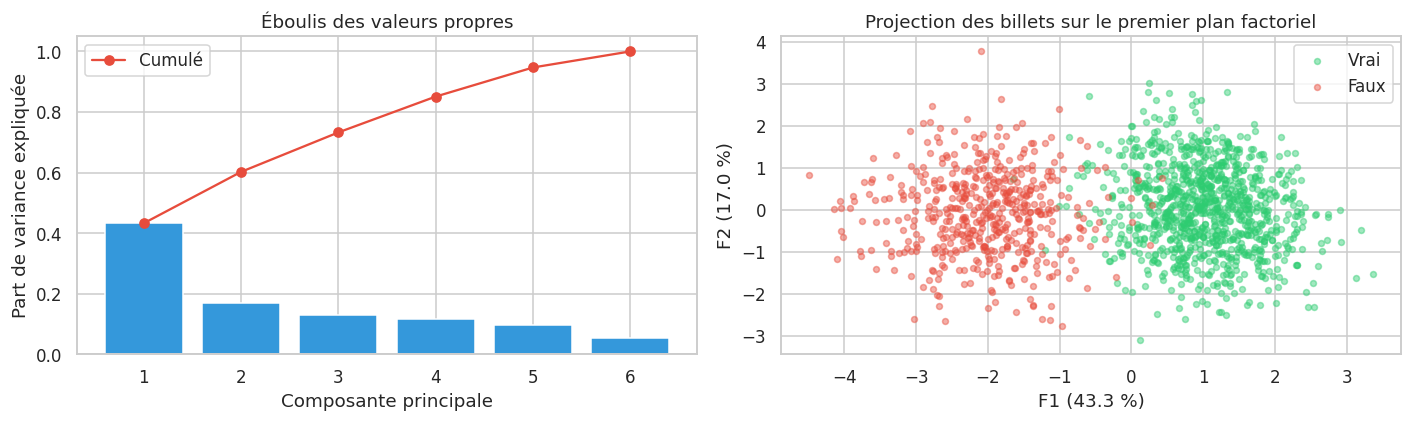

Variance expliquée par composante : [43.3 17.  13.  11.8  9.6  5.3]
Variance cumulée                  : [ 43.3  60.2  73.3  85.1  94.7 100. ]


In [26]:
X = df[features].values
y = df["is_genuine"].values

scaler_pca = StandardScaler()
X_std_full = scaler_pca.fit_transform(X)

pca = PCA(n_components=6).fit(X_std_full)

explained = pca.explained_variance_ratio_
cum = explained.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, 7), explained, color="#3498DB")
axes[0].plot(range(1, 7), cum, "o-", color="#E74C3C", label="Cumulé")
axes[0].set_title("Éboulis des valeurs propres")
axes[0].set_xlabel("Composante principale")
axes[0].set_ylabel("Part de variance expliquée")
axes[0].legend()

X_pca = pca.transform(X_std_full)
for cls, color, label in [(1, "#2ECC71", "Vrai"), (0, "#E74C3C", "Faux")]:
    mask = y == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.45, s=15,
                    color=color, label=label)
axes[1].set_xlabel(f"F1 ({explained[0]*100:.1f} %)")
axes[1].set_ylabel(f"F2 ({explained[1]*100:.1f} %)")
axes[1].set_title("Projection des billets sur le premier plan factoriel")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Variance expliquée par composante :", (explained * 100).round(1))
print("Variance cumulée                  :", (cum * 100).round(1))

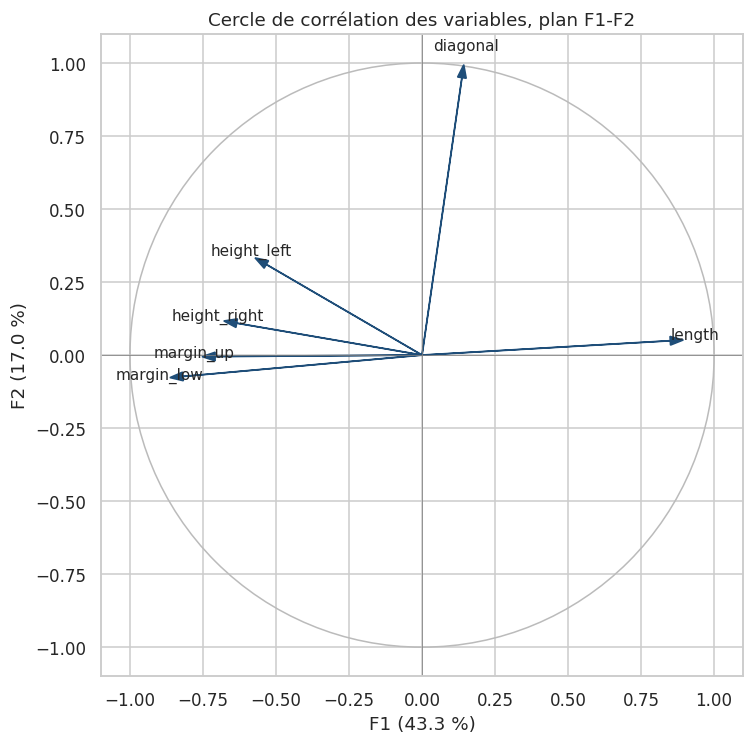

,F1,F2
diagonal,0.085,0.941
height_left,-0.331,0.308
height_right,-0.394,0.108
margin_low,-0.508,-0.072
margin_up,-0.439,-0.005
length,0.527,0.049


In [27]:
# Cercle de corrélation des variables sur le plan F1-F2
fig, ax = plt.subplots(figsize=(7, 7))
ax.add_patch(plt.Circle((0, 0), 1, color="#bbbbbb", fill=False))
for i, var in enumerate(features):
    fx = pca.components_[0, i] * np.sqrt(pca.explained_variance_[0])
    fy = pca.components_[1, i] * np.sqrt(pca.explained_variance_[1])
    ax.arrow(0, 0, fx, fy, head_width=0.03, color="#1F4E79")
    ax.text(fx * 1.1, fy * 1.1, var, ha="center", fontsize=10)
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(f"F1 ({explained[0]*100:.1f} %)")
ax.set_ylabel(f"F2 ({explained[1]*100:.1f} %)")
ax.set_title("Cercle de corrélation des variables, plan F1-F2")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

contributions = pd.DataFrame(
    pca.components_[:2].T, index=features, columns=["F1", "F2"]).round(3)
contributions

**Lecture de l'ACP.** F1 porte 43,3 % de la variance et oppose la longueur (+0,53) aux marges (-0,51 et -0,44) : c'est l'axe qui sépare les vrais des faux sur la projection, les deux nuages ne se chevauchant qu'à peine. F2 (17,0 %) est presque uniquement la diagonale (+0,94) et ne sépare rien, comme le disait déjà le d de Cohen. Le plan F1-F2 cumule 60,2 % de l'information : assez pour visualiser, pas pour modéliser, les six variables sont gardées. Un séparateur linéaire devrait suffire.

## 7. Apprentissage non supervisé : K-Means

### 7.1 Choix du nombre de clusters

Deux critères : le coude de l'inertie intra-classe, et le score de silhouette, qui vaut 1 quand les groupes sont nets et 0 quand ils se touchent.


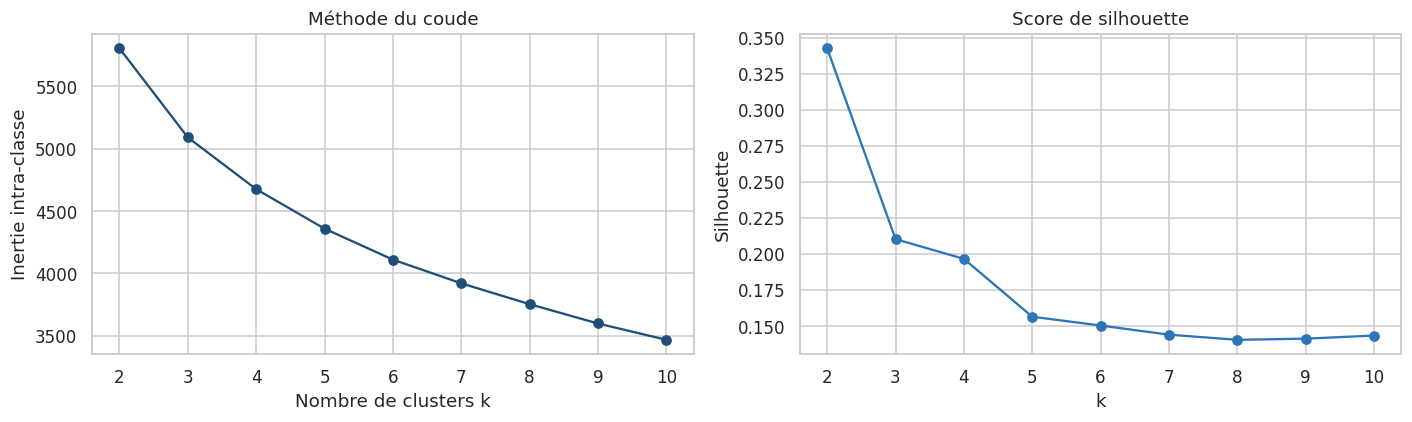

 k  inertie  silhouette
 2   5804.9       0.343
 3   5091.0       0.210
 4   4676.0       0.197
 5   4359.2       0.157
 6   4111.1       0.150
 7   3921.2       0.144
 8   3754.1       0.141
 9   3599.1       0.141
10   3468.4       0.143

k optimal selon la silhouette : 2 (score 0.343)


In [28]:
ks = list(range(2, 11))
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_std_full)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_std_full, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ks, inertias, "o-", color="#1F4E79")
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie intra-classe")

axes[1].plot(ks, silhouettes, "o-", color="#2E75B6")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

resume_k = pd.DataFrame({"k": ks,
                         "inertie": np.round(inertias, 1),
                         "silhouette": np.round(silhouettes, 3)})
print(resume_k.to_string(index=False))
print(f"\nk optimal selon la silhouette : {ks[int(np.argmax(silhouettes))]} "
      f"(score {max(silhouettes):.3f})")

**Lecture.** Le coude est à k = 2 et la silhouette y est maximale, 0,343 : deux groupes, cohérents avec les deux populations de billets, mais qui se touchent, comme la projection factorielle le montrait.

### 7.2 Caractérisation des clusters

In [29]:
km2 = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X_std_full)
df["cluster_km"] = km2.labels_

crosstab = pd.crosstab(df["cluster_km"], df["is_genuine"]).rename(columns={0: "Faux", 1: "Vrai"})
print("Répartition des classes réelles dans chaque cluster")
print(crosstab)
print()

for c in sorted(df["cluster_km"].unique()):
    ligne = crosstab.loc[c]
    purete = ligne.max() / ligne.sum()
    dominante = ligne.idxmax()
    print(f"Cluster {c} : {int(ligne.sum())} billets, classe dominante « {dominante} », "
          f"pureté {purete:.3f}")

concordance = crosstab.max(axis=1).sum() / crosstab.values.sum()
print(f"\nConcordance globale clusters / classes réelles : {concordance:.3f}")
print()
print("Profils moyens des clusters :")
print(df.groupby("cluster_km")[features].mean().round(3))

Répartition des classes réelles dans chaque cluster
is_genuine  Faux  Vrai
cluster_km            
0             14   990
1            486    10

Cluster 0 : 1004 billets, classe dominante « Vrai », pureté 0.986
Cluster 1 : 496 billets, classe dominante « Faux », pureté 0.980

Concordance globale clusters / classes réelles : 0.984

Profils moyens des clusters :
            diagonal  height_left  height_right  margin_low  margin_up  \
cluster_km                                                               
0            171.988      103.945       103.806       4.119      3.053   
1            171.899      104.200       104.153       5.221      3.352   

             length  
cluster_km           
0           113.196  
1           111.631  


In [30]:
print("Évaluation de la forme des clusters (k = 2)")
print(f"  Silhouette              : {silhouette_score(X_std_full, km2.labels_):.3f}")
print(f"  Indice de Davies-Bouldin: {davies_bouldin_score(X_std_full, km2.labels_):.3f}")
print(f"  Inertie intra-classe    : {km2.inertia_:.1f}")

Évaluation de la forme des clusters (k = 2)
  Silhouette              : 0.343
  Indice de Davies-Bouldin: 1.215
  Inertie intra-classe    : 5804.9


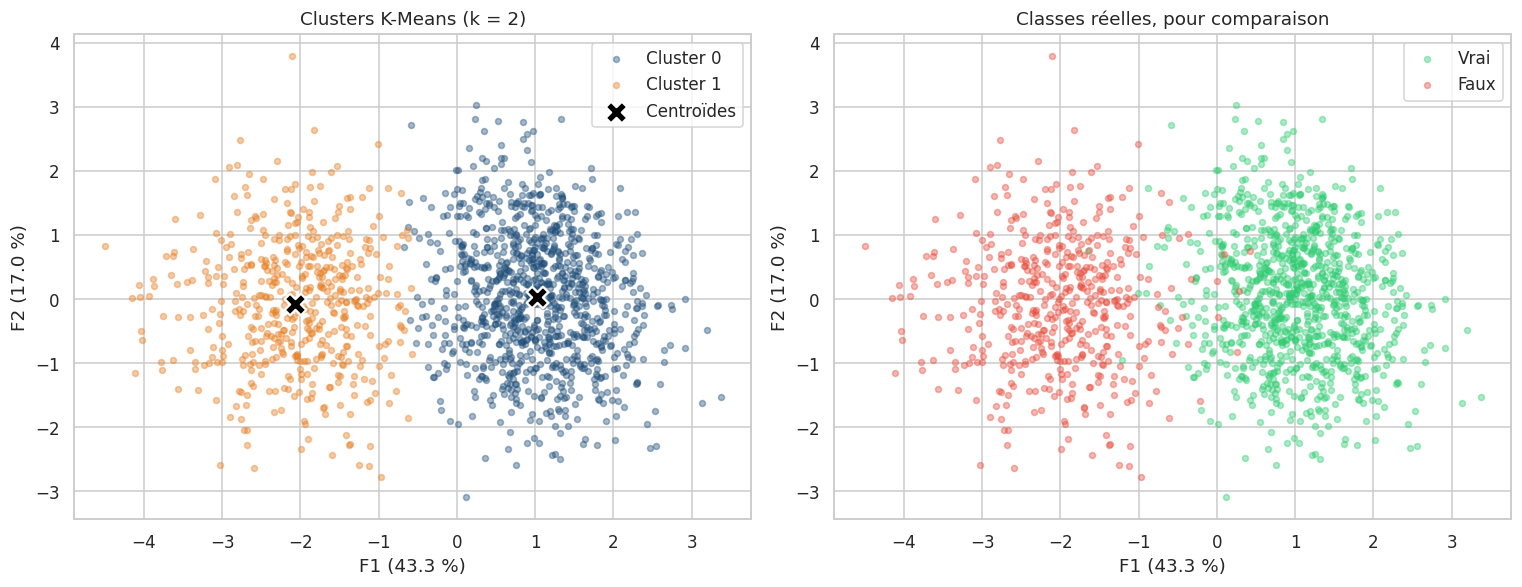

In [31]:
# Visualisation des clusters sur le premier plan factoriel
centers_pca = pca.transform(km2.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for c, color in zip([0, 1], ["#1F4E79", "#E67E22"]):
    mask = km2.labels_ == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=15,
                    color=color, label=f"Cluster {c}")
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], marker="X", s=200,
                color="black", edgecolor="white", linewidths=1.5, label="Centroïdes")
axes[0].set_xlabel(f"F1 ({explained[0]*100:.1f} %)")
axes[0].set_ylabel(f"F2 ({explained[1]*100:.1f} %)")
axes[0].set_title("Clusters K-Means (k = 2)")
axes[0].legend()

for cls, color, label in [(1, "#2ECC71", "Vrai"), (0, "#E74C3C", "Faux")]:
    mask = y == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=15,
                    color=color, label=label)
axes[1].set_xlabel(f"F1 ({explained[0]*100:.1f} %)")
axes[1].set_ylabel(f"F2 ({explained[1]*100:.1f} %)")
axes[1].set_title("Classes réelles, pour comparaison")
axes[1].legend()

plt.tight_layout()
plt.show()

**Ce que le K-Means démontre.** Sans voir l'étiquette, le K-Means retrouve les classes à 98,4 % : un cluster de 1 004 billets, pur à 98,6 % de vrais, et un cluster de 496 billets, pur à 98,0 % de faux. Silhouette 0,343, Davies-Bouldin 1,215, inertie 5 805 : forme modérée, placement juste. Profils moyens, 113,20 mm de long et 4,12 mm de marge basse pour le groupe des vrais, 111,63 mm et 5,22 mm pour celui des faux ; sur le plan factoriel, les centroïdes tombent au cœur de chaque nuage. Le signal est dans les données, pas dans l'étiquetage : les performances supervisées qui suivent ne seront pas suspectes.

## 8. Modélisation supervisée : les quatre algorithmes demandés

### 8.1 Régression logistique

**Réponse aux questions du notebook de départ.** Paramètres ajustables : la pénalité (penalty) et sa force (C), le solveur (solver), max_iter, class_weight. Comme le conseille la consigne, seul max_iter est ajusté, porté à 1000 pour garantir la convergence ; le reste est laissé par défaut, L2, C = 1, lbfgs, ce que la séparabilité presque linéaire justifie, et la validation croisée de la section 9 le confirmera.


In [32]:
from sklearn.linear_model import LogisticRegression

# 1) Initialisez une régression logistic.
    # Quels sont les paramètres ajustables de ce modèle ?
    # Bien que vous puissez laisser la majorité d'entre eux par défaut,
    # il vaut mieux, à minima, ajuster `max_iter` pour plafonner le temps de calcul.

# 2) Entrainez le modèle avec vos données X_train et y_train


# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_std, y_train)

y_pred_log = log_reg.predict(X_test_std)
y_prob_log = log_reg.predict_proba(X_test_std)[:, 1]

coefs = pd.DataFrame({
    "coefficient": log_reg.coef_[0],
    "odds ratio (par écart-type)": np.exp(log_reg.coef_[0]),
}, index=features).round(3)
print("Coefficients sur variables standardisées")
print(coefs)
print(f"\nConstante : {log_reg.intercept_[0]:+.3f}")

Coefficients sur variables standardisées
              coefficient  odds ratio (par écart-type)
diagonal            0.182                        1.200
height_left        -0.353                        0.702
height_right       -0.642                        0.526
margin_low         -2.619                        0.073
margin_up          -1.631                        0.196
length              3.686                       39.881

Constante : +1.755


**Lecture des coefficients.** Sur le test : accuracy 0,990, F1 0,9925, ROC-AUC 0,9995. Un coefficient positif augmente la probabilité de vrai billet : length domine (+3,69 ; un écart-type de longueur, 0,87 mm, multiplie par 40 la cote du vrai), les marges et les hauteurs tirent vers le faux (margin_low -2,62, margin_up -1,63, height_right -0,64, height_left -0,35), diagonal ne pèse presque rien (+0,18).

### 8.2 K plus proches voisins

Meilleur k : 13   F1 en validation croisée : 0.9944


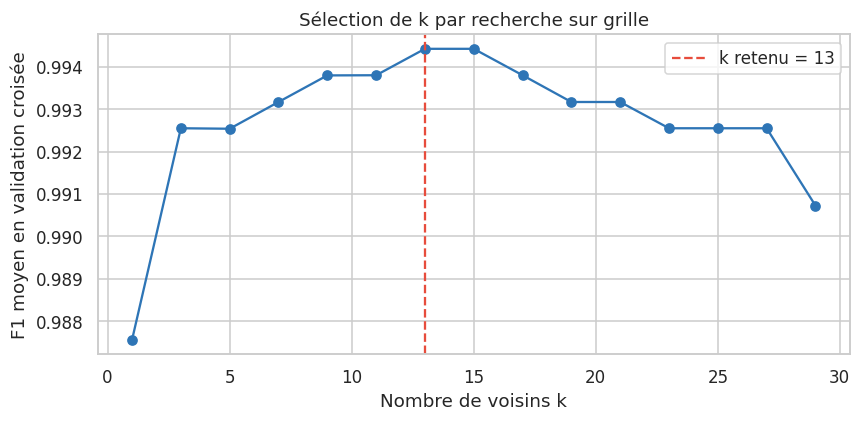

In [33]:
from sklearn.neighbors import KNeighborsClassifier

# Répéter les même étapes que pour la régression logistique mais avec le KNN.

param_grid = {"n_neighbors": list(range(1, 31, 2))}
gs_knn = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid,
                      cv=5, scoring="f1", n_jobs=-1)
gs_knn.fit(X_train_std, y_train)
best_k = gs_knn.best_params_["n_neighbors"]
print(f"Meilleur k : {best_k}   F1 en validation croisée : {gs_knn.best_score_:.4f}")

knn = gs_knn.best_estimator_
y_pred_knn = knn.predict(X_test_std)
y_prob_knn = knn.predict_proba(X_test_std)[:, 1]

# Courbe de performance selon k
scores_k = gs_knn.cv_results_["mean_test_score"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(param_grid["n_neighbors"], scores_k, "o-", color="#2E75B6")
ax.axvline(best_k, color="#E74C3C", ls="--", label=f"k retenu = {best_k}")
ax.set_xlabel("Nombre de voisins k")
ax.set_ylabel("F1 moyen en validation croisée")
ax.set_title("Sélection de k par recherche sur grille")
ax.legend()
plt.tight_layout()
plt.show()

**Lecture de la courbe de sélection.** Recherche sur grille des k impairs de 1 à 29, cinq plis, score F1 : k = 13, F1 0,9944 en validation croisée, sur un plateau large, donc un choix stable. Sur le test : accuracy 0,9867, F1 0,9900 ; le modèle décide localement, par le vote des 13 voisins.

### 8.3 Random forest

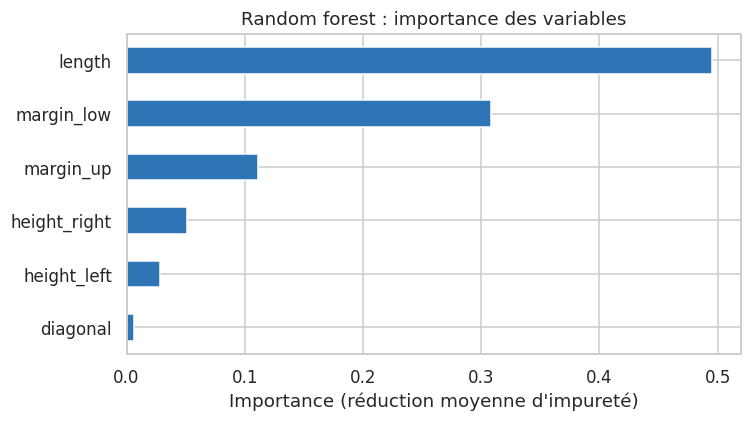

length          0.495
margin_low      0.308
margin_up       0.111
height_right    0.051
height_left     0.028
diagonal        0.006
dtype: float64


In [34]:
from sklearn.ensemble import RandomForestClassifier

# hum... devinez ce qu'il faut faire 😁.

rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2,
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)  # les arbres n'ont pas besoin de standardisation
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind="barh", color="#2E75B6", ax=ax)
ax.set_title("Random forest : importance des variables")
ax.set_xlabel("Importance (réduction moyenne d'impureté)")
plt.tight_layout()
plt.show()

print(imp.sort_values(ascending=False).round(3))

**Lecture des importances.** 300 arbres, feuilles d'au moins 2 billets, entraînés sur les données brutes, les arbres n'ayant pas besoin de standardisation. Sur le test : accuracy 0,990, F1 0,9925, la même matrice de confusion que la régression logistique. Importances : length 0,495, margin_low 0,308, margin_up 0,111, le même classement que les coefficients et les tailles d'effet.

### 8.4 K-Means utilisé comme classifieur, par les centroïdes

Le cahier des charges demande une prédiction par les centroïdes. Quatre temps : K-Means à deux clusters sur l'entraînement standardisé, sans la cible ; classe majoritaire attribuée à chaque cluster ; pour un billet, classe du centroïde le plus proche ; pseudo-probabilité par l'inverse des distances, faute de vraie probabilité.


**Réponse aux questions du notebook de départ.** Différence de nature : le K-Means n'utilise jamais la cible, il regroupe par proximité, quand les trois autres apprennent à partir de l'étiquette. Utile pour cette étude ? Oui : en section 7 il a prouvé que la structure existe sans les étiquettes, et ici il sert de point de comparaison honnête. Pas pertinent comme modèle final, sans vraie probabilité ni coefficients lisibles ; c'est dit dans le choix de la section 10.


In [35]:
from sklearn.cluster import KMeans

# Attention ! Cet algo est très différents de ceux utilisés précédemment.
# Peux-tu voir les différences ?
# Du coup, cet algo est-il utile (voir pertinent) pour cette étude ?

km_cls = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X_train_std)

mapping = {}
for c in [0, 1]:
    classe_majoritaire = int(pd.Series(y_train.values[km_cls.labels_ == c]).mode()[0])
    mapping[c] = classe_majoritaire
print("Correspondance cluster vers classe :", mapping)

dists_test = cdist(X_test_std, km_cls.cluster_centers_)
clusters_test = dists_test.argmin(axis=1)
y_pred_km = np.array([mapping[c] for c in clusters_test])

inv = 1.0 / (dists_test + 1e-9)
soft = inv / inv.sum(axis=1, keepdims=True)
clusters_classe1 = [c for c in [0, 1] if mapping[c] == 1]
y_prob_km = soft[:, clusters_classe1].sum(axis=1)

print(f"Billets du test classés vrais : {int((y_pred_km == 1).sum())} sur {len(y_pred_km)}")

Correspondance cluster vers classe : {0: 0, 1: 1}
Billets du test classés vrais : 200 sur 300


**Lecture.** Correspondance cluster 0 vers faux, cluster 1 vers vrai ; sur le test, accuracy 0,9867 et F1 0,9900 : à un cheveu des modèles supervisés, preuve que le problème est géométriquement simple.

# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀

## 9. Évaluation et comparaison

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# C'est là qu'on voit qui sont les bons 😉!

def evaluate(name, y_true, y_pred, y_prob):
    # Métriques calculées en prenant « vrai billet » (classe 1) comme classe positive.
    return {
        "modèle": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "précision": precision_score(y_true, y_pred),
        "rappel": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,
        "rappel classe faux": recall_score(y_true, y_pred, pos_label=0),
    }


results = pd.DataFrame([
    evaluate("Régression logistique", y_test, y_pred_log, y_prob_log),
    evaluate("KNN", y_test, y_pred_knn, y_prob_knn),
    evaluate("Random forest", y_test, y_pred_rf, y_prob_rf),
    evaluate("K-Means centroïdes", y_test, y_pred_km, y_prob_km),
]).set_index("modèle").round(4)
results

,accuracy,précision,rappel,f1,roc_auc,rappel classe faux
modèle,,,,,,
Régression logistique,0.9900,0.9900,0.995,0.9925,0.9995,0.98
KNN,0.9867,0.9851,0.995,0.9900,0.9994,0.97
Random forest,0.9900,0.9900,0.995,0.9925,0.9991,0.98
K-Means centroïdes,0.9867,0.9900,0.990,0.9900,0.9992,0.98


Classe positive : vrai billet. La colonne rappel classe faux est ajoutée parce que c'est elle qui compte pour l'ONCFM : la part des faux billets interceptés.

**Première lecture.** Les quatre modèles dépassent 0,986 d'accuracy. Régression logistique et random forest sont à égalité en tête, F1 0,9925 et 98 faux sur 100 interceptés ; KNN et K-Means suivent à 0,9900 de F1. Les écarts sont trop petits pour choisir sur ce seul tableau.

### 9.1 Matrices de confusion

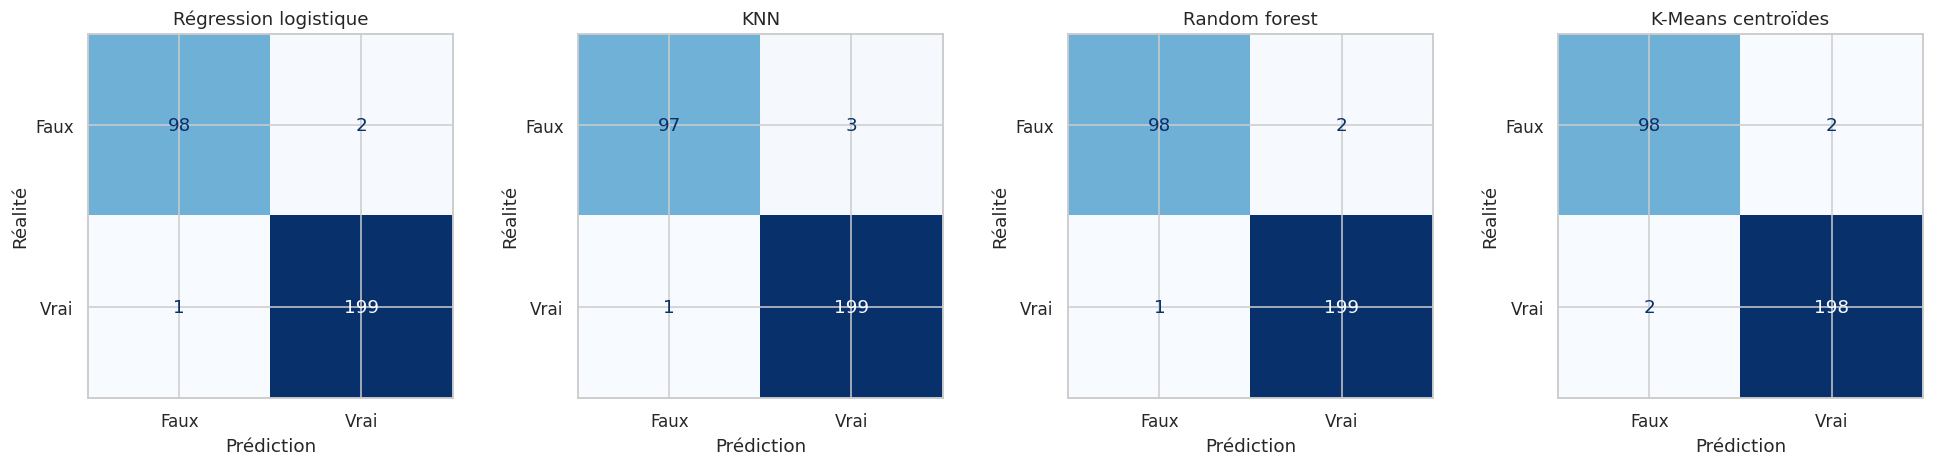

Régression logistique    faux laissés passer :  2   vrais rejetés à tort :  1
KNN                      faux laissés passer :  3   vrais rejetés à tort :  1
Random forest            faux laissés passer :  2   vrais rejetés à tort :  1
K-Means centroïdes       faux laissés passer :  2   vrais rejetés à tort :  2


In [37]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, (name, y_pred) in zip(axes, [
        ("Régression logistique", y_pred_log),
        ("KNN", y_pred_knn),
        ("Random forest", y_pred_rf),
        ("K-Means centroïdes", y_pred_km)]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Faux", "Vrai"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Réalité")
plt.tight_layout()
plt.show()

for name, y_pred in [("Régression logistique", y_pred_log), ("KNN", y_pred_knn),
                     ("Random forest", y_pred_rf), ("K-Means centroïdes", y_pred_km)]:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"{name:<24} faux laissés passer : {fp:>2}   vrais rejetés à tort : {fn:>2}")

**Lecture des matrices.** En nombre de billets sur 300 : régression logistique et random forest laissent passer 2 faux et rejettent 1 vrai ; KNN laisse passer 3 faux et rejette 1 vrai ; K-Means laisse passer 2 faux et rejette 2 vrais. Le faux laissé passer est l'erreur qui coûte.

### 9.2 Courbes ROC et courbes précision-rappel

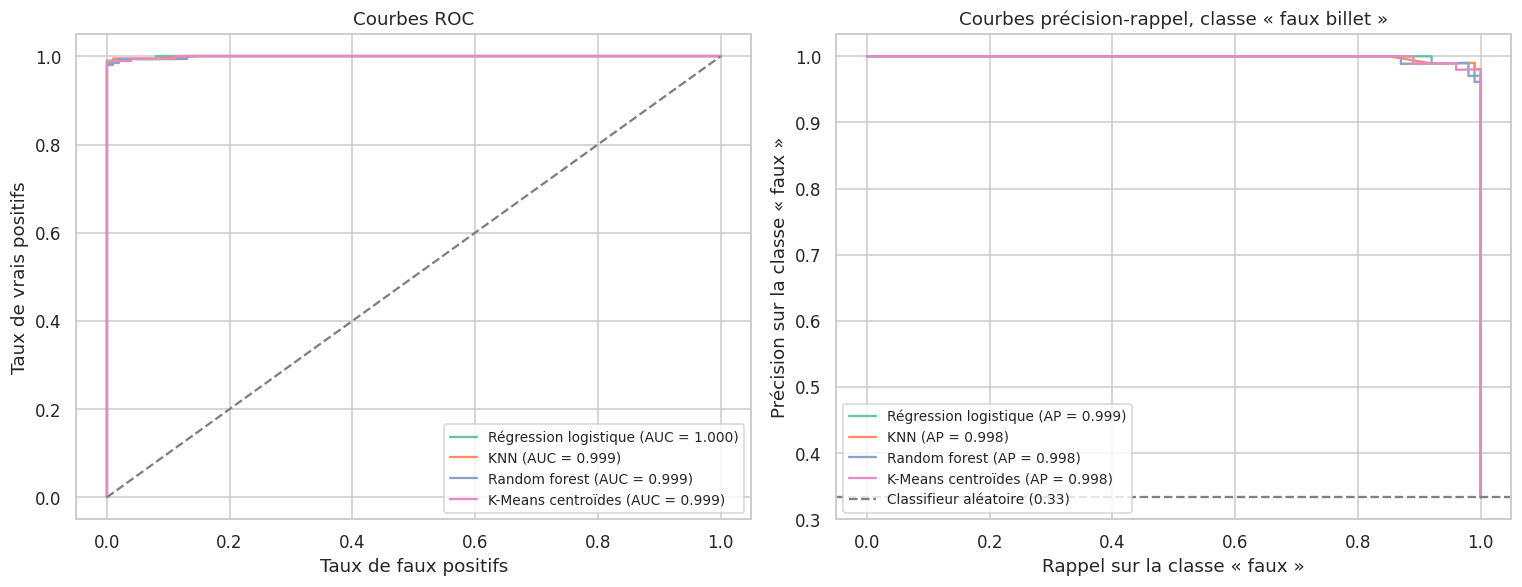

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for name, y_prob in [("Régression logistique", y_prob_log), ("KNN", y_prob_knn),
                     ("Random forest", y_prob_rf), ("K-Means centroïdes", y_prob_km)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="grey")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs")
axes[0].set_title("Courbes ROC")
axes[0].legend(loc="lower right", fontsize=9)

# Courbe précision-rappel sur la classe « faux billet », celle qui intéresse l'ONCFM
y_test_faux = (y_test == 0).astype(int)
for name, y_prob in [("Régression logistique", y_prob_log), ("KNN", y_prob_knn),
                     ("Random forest", y_prob_rf), ("K-Means centroïdes", y_prob_km)]:
    score_faux = 1 - y_prob
    pr, rc, _ = precision_recall_curve(y_test_faux, score_faux)
    ap = average_precision_score(y_test_faux, score_faux)
    axes[1].plot(rc, pr, label=f"{name} (AP = {ap:.3f})")
axes[1].axhline(y_test_faux.mean(), ls="--", color="grey",
                label=f"Classifieur aléatoire ({y_test_faux.mean():.2f})")
axes[1].set_xlabel("Rappel sur la classe « faux »")
axes[1].set_ylabel("Précision sur la classe « faux »")
axes[1].set_title("Courbes précision-rappel, classe « faux billet »")
axes[1].legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

**Lecture des courbes.** Les quatre courbes ROC sont collées au coin supérieur gauche, aires au-dessus de 0,999 : la ROC ne discrimine plus. La courbe précision-rappel, centrée sur la classe des faux, est plus exigeante quand les classes sont déséquilibrées ; elle raconte la même histoire, et c'est elle à montrer à un commanditaire qui cherche des contrefaçons.

### 9.3 Validation croisée

Les métriques ci-dessus reposent sur un seul découpage de 300 billets. Validation croisée stratifiée à cinq plis, chaque modèle dans un pipeline avec son scaler, réajusté dans chaque pli.


In [39]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pipe_log = make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
pipe_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))

cv_scores = {
    "Régression logistique": cross_val_score(pipe_log, X_full, y_full, cv=cv,
                                             scoring="f1", n_jobs=-1),
    "KNN": cross_val_score(pipe_knn, X_full, y_full, cv=cv, scoring="f1", n_jobs=-1),
    "Random forest": cross_val_score(rf, X_full, y_full, cv=cv, scoring="f1", n_jobs=-1),
}
cv_summary = pd.DataFrame({
    name: {"F1 moyen": s.mean(), "Écart-type": s.std(), "F1 minimum": s.min()}
    for name, s in cv_scores.items()
}).T.round(4)
cv_summary

,F1 moyen,Écart-type,F1 minimum
Régression logistique,0.9945,0.0024,0.9925
KNN,0.9925,0.0035,0.9876
Random forest,0.9935,0.0043,0.9900


**Lecture de la validation croisée.** F1 moyen : régression logistique 0,9945 (écart-type 0,0024), random forest 0,9935 (0,0043), KNN 0,9925 (0,0035). La régression logistique est à la fois la meilleure et la plus stable ; aucun sur-apprentissage, scores de test et de validation du même ordre.

### 9.4 Lecture métier des erreurs et arbitrage du seuil

Les deux erreurs n'ont pas le même coût : un faux classé vrai repart en circulation, un vrai classé faux part en contrôle manuel. Le seuil de 0,5 n'a rien d'obligatoire ; le remonter rend le modèle plus exigeant avant de dire « vrai ». On mesure l'effet du seuil sur le modèle retenu.


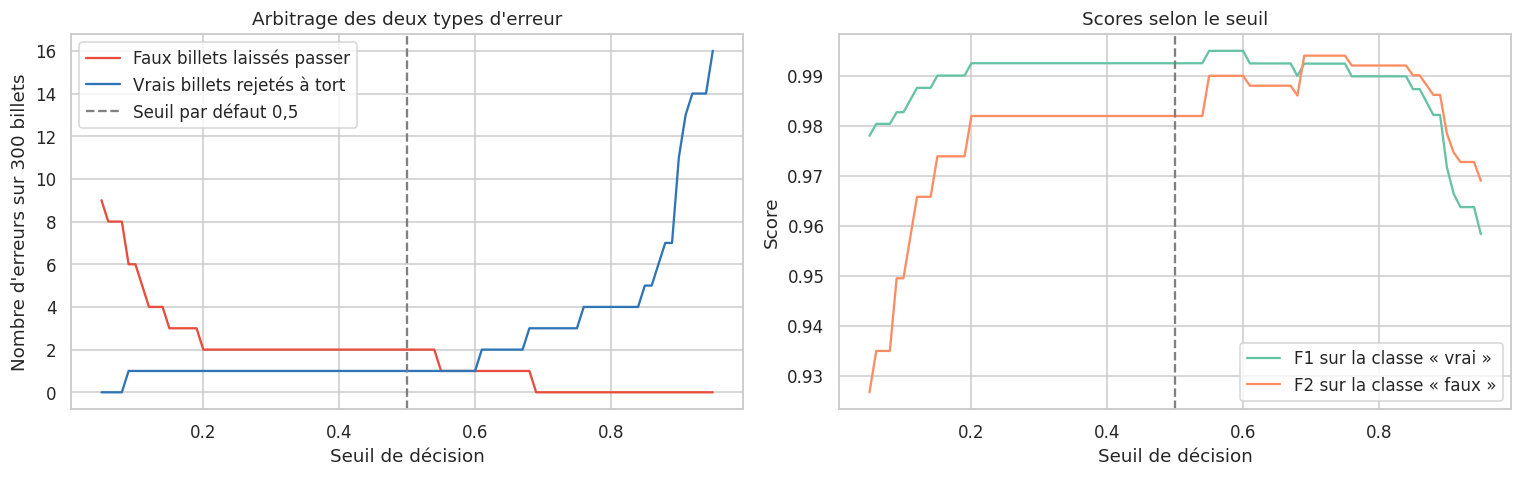

 seuil  faux laissés passer  vrais rejetés à tort  rappel classe faux  f1 classe vrai  f2 classe faux
   0.1                    6                     1                0.94          0.9827          0.9495
   0.3                    2                     1                0.98          0.9925          0.9820
   0.5                    2                     1                0.98          0.9925          0.9820
   0.7                    0                     3                1.00          0.9924          0.9940
   0.9                    0                    11                1.00          0.9717          0.9785

Seuil maximisant le F2 sur la classe « faux » : 0.69
  faux laissés passer  : 0
  vrais rejetés à tort : 3

Seuil minimal interceptant 100 % des faux du test : 0.69
  coût : 3 vrais billets envoyés en contrôle manuel


In [40]:
seuils = np.linspace(0.05, 0.95, 91)
lignes = []
for s in seuils:
    pred = (y_prob_log >= s).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    lignes.append({
        "seuil": s,
        "faux laissés passer": fp,
        "vrais rejetés à tort": fn,
        "rappel classe faux": tn / (tn + fp) if (tn + fp) else np.nan,
        "f1 classe vrai": f1_score(y_test, pred, zero_division=0),
        "f2 classe faux": fbeta_score(y_test, pred, beta=2, pos_label=0, zero_division=0),
    })
grille_seuils = pd.DataFrame(lignes)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(grille_seuils["seuil"], grille_seuils["faux laissés passer"],
             color="#E74C3C", label="Faux billets laissés passer")
axes[0].plot(grille_seuils["seuil"], grille_seuils["vrais rejetés à tort"],
             color="#2E75B6", label="Vrais billets rejetés à tort")
axes[0].axvline(0.5, ls="--", color="grey", label="Seuil par défaut 0,5")
axes[0].set_xlabel("Seuil de décision")
axes[0].set_ylabel("Nombre d'erreurs sur 300 billets")
axes[0].set_title("Arbitrage des deux types d'erreur")
axes[0].legend()

axes[1].plot(grille_seuils["seuil"], grille_seuils["f1 classe vrai"],
             label="F1 sur la classe « vrai »")
axes[1].plot(grille_seuils["seuil"], grille_seuils["f2 classe faux"],
             label="F2 sur la classe « faux »")
axes[1].axvline(0.5, ls="--", color="grey")
axes[1].set_xlabel("Seuil de décision")
axes[1].set_ylabel("Score")
axes[1].set_title("Scores selon le seuil")
axes[1].legend()

plt.tight_layout()
plt.show()

apercu = grille_seuils[grille_seuils["seuil"].round(2).isin([0.10, 0.30, 0.50, 0.70, 0.90])]
print(apercu.round(4).to_string(index=False))

meilleur_f2 = grille_seuils.loc[grille_seuils["f2 classe faux"].idxmax()]
print(f"\nSeuil maximisant le F2 sur la classe « faux » : {meilleur_f2['seuil']:.2f}")
print(f"  faux laissés passer  : {int(meilleur_f2['faux laissés passer'])}")
print(f"  vrais rejetés à tort : {int(meilleur_f2['vrais rejetés à tort'])}")

seuil_zero_faux = grille_seuils[grille_seuils["faux laissés passer"] == 0]["seuil"].min()
ligne_zero = grille_seuils[grille_seuils["seuil"] == seuil_zero_faux].iloc[0]
print(f"\nSeuil minimal interceptant 100 % des faux du test : {seuil_zero_faux:.2f}")
print(f"  coût : {int(ligne_zero['vrais rejetés à tort'])} vrais billets envoyés en contrôle manuel")

**Ce que montre cette analyse.** Au seuil de 0,5 : 2 faux laissés passer sur 100, 1 vrai en contrôle sur 200, avec des probabilités très tranchées, presque toutes sous 0,01 ou au-dessus de 0,99. À 0,69, tous les faux du test sont interceptés au prix de 3 vrais en contrôle, et le F2 sur la classe faux passe de 0,982 à 0,994. Le seuil de 0,5 est conservé dans le livrable : l'optimum est estimé sur 300 billets seulement et l'arbitrage des coûts appartient à l'ONCFM. Le levier existe, il est mesuré, et l'application permet de le régler sans réentraîner.

In [41]:
for name, y_pred in [("Régression logistique", y_pred_log), ("KNN", y_pred_knn),
                     ("Random forest", y_pred_rf), ("K-Means centroïdes", y_pred_km)]:
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Faux", "Vrai"], digits=3))

=== Régression logistique ===
              precision    recall  f1-score   support

        Faux      0.990     0.980     0.985       100
        Vrai      0.990     0.995     0.993       200

    accuracy                          0.990       300
   macro avg      0.990     0.988     0.989       300
weighted avg      0.990     0.990     0.990       300

=== KNN ===
              precision    recall  f1-score   support

        Faux      0.990     0.970     0.980       100
        Vrai      0.985     0.995     0.990       200

    accuracy                          0.987       300
   macro avg      0.987     0.982     0.985       300
weighted avg      0.987     0.987     0.987       300

=== Random forest ===
              precision    recall  f1-score   support

        Faux      0.990     0.980     0.985       100
        Vrai      0.990     0.995     0.993       200

    accuracy                          0.990       300
   macro avg      0.990     0.988     0.989       300
weighted a

## 10. Choix du modèle final

**Modèle retenu : la régression logistique.**

Performance : à égalité avec le random forest, F1 0,9925 et ROC-AUC 0,9995 contre 0,9991 ; KNN et K-Means à 0,9900 de F1. Interprétabilité : chaque verdict s'explique par les coefficients, ce qui compte pour un organisme public. Stabilité : meilleur F1 moyen et plus faible écart-type en validation croisée. Coût : un produit scalaire et une sigmoïde, contre 300 arbres ou une distance à 1 200 points. Le random forest était défendable mais surdimensionné pour un problème presque linéaire ; le KNN est moins lisible et plus coûteux ; le K-Means est remarquable pour ce qu'il est, sans vraie probabilité.

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

### 10.1 Sauvegarde du pipeline complet

On sauvegarde l'objet complet, StandardScaler et régression logistique dans un même Pipeline, pour ne pas recoder la standardisation dans l'application ; on y joint le modèle d'imputation et quelques métadonnées, dans un dictionnaire unique, afin de traiter un fichier de production comportant des valeurs manquantes.


In [42]:
from sklearn.pipeline import make_pipeline
import joblib

# Utilisez make_pipeline pour inclure toutes les étapes nécessaires
# à la prédiction de si un billet est vrai ou faux.

# Sauvegardez votre modèle à l'aide de la librairie joblib.
# Le Pipeline nommé ci-dessous est l'équivalent explicite de make_pipeline.

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

# Entraînement final sur l'intégralité des données disponibles
final_pipeline.fit(X_full, y_full)

artefact = {
    "pipeline": final_pipeline,
    "features": features,
    "imputation": {
        "cible": "margin_low",
        "predicteurs": predictors,
        "coefficients": ols.params.to_dict(),
        "r2_ajuste": float(ols.rsquared_adj),
    },
    "seuil": 0.5,
    "metadata": {
        "auteur": "Charles Lippens",
        "projet": "P12 ONCFM, détection de faux billets",
        "date": "août 2026",
        "sklearn_version": sklearn.__version__,
        "n_entrainement": int(len(X_full)),
        "f1_test": float(f1_score(y_test, y_pred_log)),
        "roc_auc_test": float(roc_auc_score(y_test, y_prob_log)),
    },
}

MODEL_PATH = "modele_detection_billets.joblib"
joblib.dump(artefact, MODEL_PATH)
print("Modèle sauvegardé :", MODEL_PATH)
print("Coefficients d'imputation embarqués :",
      {k: round(v, 4) for k, v in artefact["imputation"]["coefficients"].items()})

Modèle sauvegardé : modele_detection_billets.joblib
Coefficients d'imputation embarqués : {'const': 22.9948, 'diagonal': -0.1111, 'height_left': 0.1841, 'height_right': 0.2571, 'margin_up': 0.2562, 'length': -0.4091}


In [43]:
# Vérification : on recharge et on prédit, pour s'assurer que l'objet est exploitable tel quel
charge = joblib.load(MODEL_PATH)
pipe_charge = charge["pipeline"]
echantillon = X_full.head(3)
print("Prédictions   :", pipe_charge.predict(echantillon).tolist())
print("Probabilités  :", pipe_charge.predict_proba(echantillon)[:, 1].round(4).tolist())
print("Version scikit-learn d'entraînement :", charge["metadata"]["sklearn_version"])

Prédictions   : [1, 1, 1]
Probabilités  : [0.7038, 0.9999, 0.9985]
Version scikit-learn d'entraînement : 1.6.1


**Contrôle du rechargement.** Pipeline réentraîné sur les 1 500 billets puis sérialisé dans modele_detection_billets.joblib avec les coefficients d'imputation, la liste des variables, le seuil et les métadonnées. Rechargé, il prédit trois vrais billets de contrôle avec des probabilités de 0,7038, 0,9999 et 0,9985 : l'objet est complet et autonome.

### 10.2 Test sur le fichier de production

In [44]:
PROD_PATH = "billets_production.csv"
if not os.path.exists(PROD_PATH):
    for alt in ("../data/billets_production.csv", "data/billets_production.csv"):
        if os.path.exists(alt):
            PROD_PATH = alt
            break

prod = pd.read_csv(PROD_PATH)
print("Valeurs manquantes dans le fichier de production :", int(prod.isna().sum().sum()))
prod

Valeurs manquantes dans le fichier de production : 0


,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5


In [45]:
X_prod = prod[features]
preds = final_pipeline.predict(X_prod)
probas = final_pipeline.predict_proba(X_prod)[:, 1]

resultat = prod.copy()
resultat["prediction"] = preds
resultat["probabilite_vrai"] = probas.round(4)
resultat["verdict"] = np.where(preds == 1, "VRAI BILLET", "FAUX BILLET")
resultat

,diagonal,height_left,height_right,margin_low,margin_up,length,id,prediction,probabilite_vrai,verdict
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,0,0.0011,FAUX BILLET
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,0,0.0001,FAUX BILLET
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,0,0.0003,FAUX BILLET
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4,1,0.9794,VRAI BILLET
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5,1,0.9999,VRAI BILLET


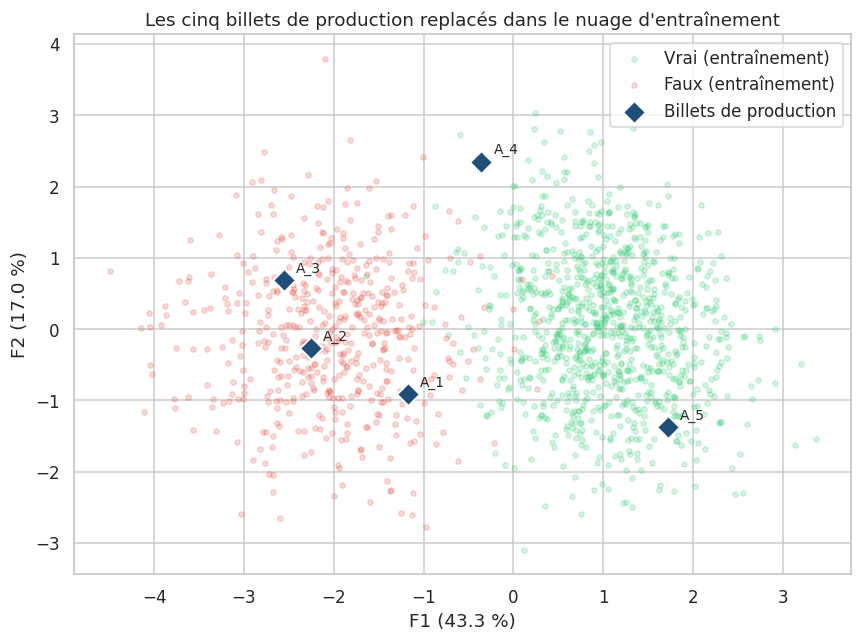

In [46]:
# Situation des cinq billets de production sur le premier plan factoriel
X_prod_std = scaler_pca.transform(X_prod.values)
X_prod_pca = pca.transform(X_prod_std)

fig, ax = plt.subplots(figsize=(8, 6))
for cls, color, label in [(1, "#2ECC71", "Vrai (entraînement)"),
                          (0, "#E74C3C", "Faux (entraînement)")]:
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.2, s=12, color=color, label=label)
ax.scatter(X_prod_pca[:, 0], X_prod_pca[:, 1], marker="D", s=110,
           color="#1F4E79", edgecolor="white", linewidths=1.2, label="Billets de production")
for i, ident in enumerate(prod["id"]):
    ax.annotate(ident, (X_prod_pca[i, 0], X_prod_pca[i, 1]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xlabel(f"F1 ({explained[0]*100:.1f} %)")
ax.set_ylabel(f"F2 ({explained[1]*100:.1f} %)")
ax.set_title("Les cinq billets de production replacés dans le nuage d'entraînement")
ax.legend()
plt.tight_layout()
plt.show()

**Lecture du test de production.** Sur billets_production.csv : A_1, A_2 et A_3 sont des faux, probabilité d'être vrai de 0,0011, 0,0001 et 0,0003 ; A_4 et A_5 sont des vrais, 0,9794 et 0,9999. Sur le plan factoriel, les cinq tombent au cœur d'un nuage, loin de la zone de recouvrement : aucun cas limite.

## Conclusion

Le cahier des charges est couvert : analyse descriptive des 1 500 billets, quatre algorithmes comparés avec l'analyse des faux positifs et des faux négatifs, modèle final exploitable dans un script. La régression logistique est retenue, F1 0,9925 et ROC-AUC 0,9995 sur le test, à égalité avec le random forest, plus lisible, plus stable et moins coûteuse ; le pipeline complet est sérialisé avec le modèle d'imputation et alimente l'application.

Limites : 1 500 billets suffisent pour ce problème, pas pour anticiper des contrefaçons d'un type nouveau ; les probabilités, très tranchées, ne sont pas calibrées et se lisent comme un indice de confiance ; le modèle suppose des mesures de scan fiables et stables. Pistes : calibrer les probabilités, ajouter une détection d'anomalies pour les billets qui ne ressemblent à aucune population connue, suivre la dérive et réentraîner périodiquement, exposer le modèle derrière une interface si le volume le justifie.
